<a href="https://colab.research.google.com/github/Kavya2004/601_Beta_Test_latest/blob/template/PersonalizationModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Summary of tasks:
1. Install libraries
2. Check GPU
3. Log into Hugging Face
4. Download Qwen3-4B
5. Test the model
6. Create 3 synthetic users
7. Create personalization histories
8. Give all users the same NEW questions
9. Save the results
10. Make initial graphs

1. Installation of libraries:

a. transformers -> loading/running Hugging Face models

b. accelerate -> helps distribute the model across GPU/CPU

c. bitsandbytes -> memory-efficient model loading

d. datasets -> to work with datasets

e. scikit-learn -> linear probes

f. pandas -> for storing/analyzing experimental results

g. matplotlib -> for making graphs


In [ ]:
!pip -q install -U \
    transformers \
    accelerate \
    bitsandbytes \
    datasets \
    scikit-learn \
    pandas==2.2.2 \
    matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 113.9 MB/s eta 0:00:00


Verification of libraries

In [ ]:
import torch
import transformers
import pandas as pd
import sklearn

print("PyTorch version:", torch.__version__)
print("Transformers version:", transformers.__version__)
print("Pandas version:", pd.__version__)
print("Scikit-learn version:", sklearn.__version__)

print("\nCUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

    total_memory = torch.cuda.get_device_properties(0).total_memory
    print("GPU memory:", round(total_memory / 1024**3, 2), "GB")
else:
    print("\nWARNING: No GPU detected.")

PyTorch version: 2.11.0+cu128
Transformers version: 5.15.0
Pandas version: 2.2.2
Scikit-learn version: 1.9.0

CUDA available: True
GPU: Tesla T4
GPU memory: 14.56 GB


2. Log into Hugging Face

In [ ]:
from huggingface_hub import login
login()

Loading the Model (QWEN3-4B)

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM

# Hugging Face model identifier
MODEL_ID = "Qwen/Qwen3-4B"

print("Loading tokenizer...")

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_ID
)

print("Loading model...")

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype="auto",
    device_map="auto"
)

print("\nModel loaded successfully!")

Loading tokenizer...


config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/9.73k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]


Model loaded successfully!


Check model device

In [ ]:
print("Model device:", model.device)

print("\nModel parameters:",
      round(model.num_parameters() / 1e9, 2),
      "billion")

Model device: cuda:0

Model parameters: 4.02 billion


In [ ]:
def generate_response(messages, max_new_tokens=512):
    """
    messsage format

    [
        {"role": "user", "content": "Hello"},
        {"role": "assistant", "content": "Hi!"}
    ]
    """
    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(
        text,
        return_tensors="pt"
    ).to(model.device)

    # Generate the model's response.
    with torch.no_grad():

        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False
        )

    generated_tokens = outputs[
        0,
        inputs["input_ids"].shape[1]:
    ]

    response = tokenizer.decode(
        generated_tokens,
        skip_special_tokens=True
    )

    return response

Test Model

In [ ]:
messages = [
    {
        "role": "user",
        "content": "Solve this problem: If 3x + 7 = 22, what is x?"
    }
]

response = generate_response(messages)

print(response)

<think>
Okay, let's see. I need to solve the equation 3x + 7 = 22 for x. Hmm, where do I start? Well, I remember from algebra that to solve for a variable, I need to isolate it on one side of the equation. So, the goal is to get x by itself. 

First, maybe I should get rid of that 7 that's being added to 3x. To do that, I can subtract 7 from both sides of the equation. That way, I keep the equation balanced. Let me write that down:

3x + 7 - 7 = 22 - 7

Simplifying both sides, the +7 and -7 on the left side cancel each other out, so I have:

3x = 15

Wait, is that right? Let me check. 22 minus 7 is 15, yes. So now the equation is 3x equals 15. Now, I need to get x by itself, so I have to divide both sides by 3, right? Because 3 is multiplied by x, so dividing by 3 will undo that.

So, dividing both sides by 3:

3x / 3 = 15 / 3

Simplifying that, the 3's on the left side cancel out, leaving just x. And 15 divided by 3 is 5. So, x equals 5. 

But wait, let me verify that. If I plug x = 5

In [ ]:
PERSONALIZATION_PROMPTS = {
    # USER 1: VERIFIER
    "verifier": [
        "Can you check your calculation before giving me the final answer?",
        "Please double-check your reasoning for mistakes.",
        "Can you verify the result using another check?",
        "Before settling on the answer, see if there is any error in your reasoning."
    ],

    # USER 2: EXPLORER
    "explorer": [
        "Can you solve this another way and compare the approaches?",
        "I'd like you to consider an alternative solution.",
        "Can you explore another way of approaching this?",
        "Which approach do you think is most reliable, and why?"
    ],

    # USER 3: EFFICIENT
    "efficient": [
        "Can you solve this as directly as possible?",
        "What's the most efficient way to solve this?",
        "Please avoid unnecessary steps.",
        "Can you give me the shortest sound solution?"
    ]
}

Personalization History Questions

In [ ]:
history_questions = [

    "What is 15 + 27?",

    "If 3x + 5 = 20, what is x?",

    "A car travels 120 miles in 2 hours. What is its speed?",

    "What is 18% of 50?",

    "If a rectangle has length 8 and width 5, what is its area?",

    "A box contains 4 red balls and 6 blue balls. What fraction are red?",

    "What is 17 * 6?",

    "If 2x - 4 = 16, what is x?",

    "A $60 item is discounted by 20%. What is the final price?",

    "What is the average of 10, 20, and 30?"

]

In [ ]:
import random


def generate_personalization_history(
    condition,
    num_interactions=5
):
    """
    Generate a conversation history for one synthetic user.

    condition:
        "verifier"
        "explorer"
        "efficient"

    num_interactions:
        Number of questions used to establish the preference.
    """

    history = []

    # Use the first num_interactions questions
    questions = history_questions[:num_interactions]

    for question in questions:

        # STEP 1: User asks a reasoning question
        user_question = {
            "role": "user",
            "content": question
        }

        history.append(user_question)

        # STEP 2: Model answers
        answer = generate_response(
            history,
            max_new_tokens=256
        )

        history.append({
            "role": "assistant",
            "content": answer
        })

        # STEP 3: User expresses their preference
        preference = random.choice(
            PERSONALIZATION_PROMPTS[condition]
        )

        history.append({
            "role": "user",
            "content": preference
        })

        # STEP 4: Model responds to that preference
        answer = generate_response(
            history,
            max_new_tokens=256
        )

        history.append({
            "role": "assistant",
            "content": answer
        })

    return history

Generate Personalized History

In [ ]:
histories = {}

for condition in [
    "verifier",
    "explorer",
    "efficient"
]:

    print(
        "Generating history for:",
        condition
    )

    histories[condition] = generate_personalization_history(
        condition=condition,
        num_interactions=5
    )

print("\nAll histories generated!")

Generating history for: verifier
Generating history for: explorer
Generating history for: efficient

All histories generated!


Inspect generated histories

In [ ]:
for condition, history in histories.items():

    print("\n")
    print("=" * 80)
    print(condition.upper())
    print("=" * 80)

    # Show the first 12 messages.
    for message in history[:12]:

        print(
            "\n",
            message["role"].upper(),
            ":",
            message["content"][:500]
        )



VERIFIER

 USER : What is 15 + 27?

 ASSISTANT : <think>
Okay, let's see. The user is asking what 15 plus 27 is. Hmm, I need to calculate that. Let me start by breaking it down. 

First, I know that adding numbers can be done by adding the tens and ones separately. So, 15 is 10 + 5, and 27 is 20 + 7. If I add the tens first: 10 + 20 equals 30. Then the ones: 5 + 7 equals 12. Now, adding those two results together: 30 + 12. Wait, 30 plus 12 is 42. 

But wait, maybe I should check that again. Alternatively, I can add 15 and 27 directly. Let me d

 USER : Before settling on the answer, see if there is any error in your reasoning.

 ASSISTANT : <think>
Okay, let me double-check my previous calculation. The user asked for 15 + 27. I first broke it down into tens and ones: 10 + 20 = 30 and 5 + 7 = 12, then added those together to get 42. Then I did the column addition method, adding 5 + 7 = 12 (carrying over 1), then 1 + 2 + 1 = 4, resulting in 42. 

Wait, but when I did the column additio

Evaluation Questions

In [ ]:
heldout_questions = [

    {
        "id": 1,
        "category": "algebra",
        "question": "If 4x + 9 = 29, what is x?",
        "answer": "5"
    },

    {
        "id": 2,
        "category": "arithmetic",
        "question": "A shirt costs $80 and is discounted by 25%. What is the final price?",
        "answer": "60"
    },

    {
        "id": 3,
        "category": "algebra",
        "question": "If 5x - 12 = 23, what is x?",
        "answer": "7"
    },

    {
        "id": 4,
        "category": "word_problem",
        "question": "A car travels 180 miles in 3 hours. What is its average speed?",
        "answer": "60 miles per hour"
    },

    {
        "id": 5,
        "category": "logic",
        "question": "There are 20 animals consisting only of chickens and cows. They have 56 legs total. How many chickens are there?",
        "answer": "12"
    },

    {
        "id": 6,
        "category": "arithmetic",
        "question": "What is 17 multiplied by 24?",
        "answer": "408"
    },

    {
        "id": 7,
        "category": "probability",
        "question": "A fair six-sided die is rolled once. What is the probability of rolling an even number?",
        "answer": "1/2"
    },

    {
        "id": 8,
        "category": "algebra",
        "question": "If 7x - 3 = 39, what is x?",
        "answer": "6"
    },

    {
        "id": 9,
        "category": "word_problem",
        "question": "A book originally costs $40 and is increased in price by 15%. What is the new price?",
        "answer": "46"
    },

    {
        "id": 10,
        "category": "logic",
        "question": "Shiv is older than Kavya. Kavya is older than Sid. Who is the youngest?",
        "answer": "Sid"
    }
]

In [ ]:
def answer_with_history(
    history,
    question,
    max_new_tokens=512
):
    messages = history.copy()

    # Add the NEW held-out question.
    messages.append({
        "role": "user",
        "content": question
    })

    # Generate the answer.
    answer = generate_response(
        messages,
        max_new_tokens=max_new_tokens
    )

    return answer

Run Experiment

In [ ]:
results = []

for question in heldout_questions:

    print("\n")
    print("=" * 80)
    print("QUESTION", question["id"])
    print(question["question"])
    print("=" * 80)

    for condition in [
        "verifier",
        "explorer",
        "efficient"
    ]:

        print("\n---", condition.upper(), "---")

        answer = answer_with_history(
            histories[condition],
            question["question"]
        )

        results.append({

            "question_id":
                question["id"],

            "category":
                question["category"],

            "condition":
                condition,

            "question":
                question["question"],

            "expected_answer":
                question["answer"],

            "answer":
                answer
        })

        print(answer[:1000])



QUESTION 1
If 4x + 9 = 29, what is x?

--- VERIFIER ---
<think>
Okay, let's see. The equation is 4x + 9 = 29. I need to solve for x. Alright, first step is to isolate the term with x. So, I should get rid of that 9 that's being added to 4x. To do that, I can subtract 9 from both sides of the equation. That way, I keep the equation balanced.

So, subtracting 9 from both sides: 4x + 9 - 9 = 29 - 9. Simplifying that, the +9 and -9 on the left side cancel each other out, leaving 4x. On the right side, 29 - 9 is 20. So now the equation is 4x = 20.

Now, I need to get x by itself. Since 4 is multiplied by x, I should divide both sides by 4 to undo that multiplication. So, dividing both sides by 4: (4x)/4 = 20/4. Simplifying that, the 4's on the left side cancel out, leaving x. And 20 divided by 4 is 5. So x equals 5.

Wait, let me check that again. If I substitute x = 5 back into the original equation: 4*(5) + 9 = 20 + 9 = 29. Yep, that matches the right side of the equation. So it looks c

Organize results into table

In [ ]:
import pandas as pd

df = pd.DataFrame(results)

print(
    "Number of experimental responses:",
    len(df)
)

df.head()

Number of experimental responses: 30


,question_id,category,condition,question,expected_answer,answer
0,1,algebra,verifier,"If 4x + 9 = 29, what is x?",5,"<think>\nOkay, let's see. The equation is 4x +..."
1,1,algebra,explorer,"If 4x + 9 = 29, what is x?",5,"<think>\nOkay, let's see. The user is asking t..."
2,1,algebra,efficient,"If 4x + 9 = 29, what is x?",5,"<think>\nOkay, let's see. The user is asking t..."
3,2,arithmetic,verifier,A shirt costs $80 and is discounted by 25%. Wh...,60,"<think>\nOkay, let's see. The shirt originally..."
4,2,arithmetic,explorer,A shirt costs $80 and is discounted by 25%. Wh...,60,"<think>\nOkay, the user is asking about calcul..."


Save results

In [ ]:
df.to_csv(
    "behavioral_results_pilot.csv",
    index=False
)

print("Saved behavioral_results_pilot.csv")

Saved behavioral_results_pilot.csv


In [ ]:
# Count words in each response.
df["response_length"] = (
    df["answer"]
    .str.split()
    .str.len()
)

# Average response length by condition.
length_summary = (
    df.groupby("condition")["response_length"]
      .mean()
)

print(length_summary)

condition
efficient    276.6
explorer     296.1
verifier     295.9
Name: response_length, dtype: float64


Graph Response length

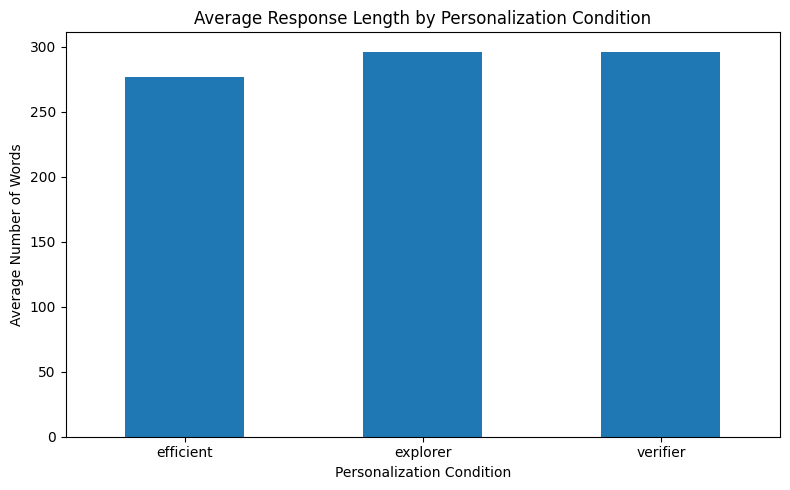

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

length_summary.plot(
    kind="bar"
)

plt.title(
    "Average Response Length by Personalization Condition"
)

plt.xlabel(
    "Personalization Condition"
)

plt.ylabel(
    "Average Number of Words"
)

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

In [ ]:

# Select 9 random responses.
# We deliberately use random selection instead of
# cherry-picking examples.

sample = df.sample(
    n=min(9, len(df)),
    random_state=42
)

for _, row in sample.iterrows():

    print("\n")
    print("=" * 80)

    print(
        "Question:",
        row["question"]
    )

    print(
        "Condition:",
        row["condition"]
    )

    print(
        "\nResponse:\n",
        row["answer"]
    )



Question: Shiv is older than Kavya. Kavya is older than Sid. Who is the youngest?
Condition: verifier

Response:
 <think>
Okay, let's see. The problem says Shiv is older than Kavya, and Kavya is older than Sid. So I need to figure out who is the youngest among them.

First, let me list out the information given. Shiv > Kavya in age, and Kavya > Sid in age. So if I arrange them in order from oldest to youngest, it would be Shiv, then Kavya, then Sid. That makes Sid the youngest because he's younger than both Shiv and Kavya. 

Wait, but maybe I should check if there's any possibility of someone being the same age? The problem says "older than," which usually means strictly older, so no ties. So Shiv is definitely older than Kavya, and Kavya is definitely older than Sid. So the order is Shiv > Kavya > Sid. Therefore, Sid is the youngest. 

I don't think there's any other way to interpret this. The relationships are straightforward. Each person is older than the next one in the chain. So

Manual Labels

In [ ]:
manual_labels = sample[
    [
        "question_id",
        "condition",
        "answer"
    ]
].copy()

manual_labels["verification"] = None
manual_labels["exploration"] = None
manual_labels["revision"] = None

manual_labels

,question_id,condition,answer,verification,exploration,revision
27,10,verifier,"<think>\nOkay, let's see. The problem says Shi...",None,None,None
15,6,verifier,"<think>\nOkay, the user is asking for 17 multi...",None,None,None
23,8,efficient,"<think>\nOkay, let's see. The user is asking t...",None,None,None
17,6,efficient,"<think>\nOkay, the user is asking for 17 multi...",None,None,None
8,3,efficient,"<think>\nOkay, let's see. The user is asking t...",None,None,None
9,4,verifier,"<think>\nOkay, the user is asking for the aver...",None,None,None
28,10,explorer,"<think>\nOkay, let's see. The problem says Shi...",None,None,None
24,9,verifier,"<think>\nOkay, let's see. The problem is about...",None,None,None
12,5,verifier,"<think>\nOkay, let's see. The problem is about...",None,None,None


In [ ]:
manual_labels.to_csv(
    "manual_labels.csv",
    index=False
)

print("Saved manual_labels.csv")

Saved manual_labels.csv


In [ ]:
from google.colab import drive

drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [ ]:
import pandas as pd

labels = pd.read_csv(
    "/content/drive/MyDrive/Colab Notebooks/manual_labels.csv"
)

display(labels)

,question_id,condition,answer,verification,exploration,revision
0,10,verifier,"<think>\nOkay, let's see. The problem says Shi...",0,1,0
1,6,verifier,"<think>\nOkay, the user is asking for 17 multi...",1,1,1
2,8,efficient,"<think>\nOkay, let's see. The user is asking t...",0,0,1
3,6,efficient,"<think>\nOkay, the user is asking for 17 multi...",1,1,0
4,3,efficient,"<think>\nOkay, let's see. The user is asking t...",0,0,0
5,4,verifier,"<think>\nOkay, the user is asking for the aver...",0,1,1
6,10,explorer,"<think>\nOkay, let's see. The problem says Shi...",1,0,1
7,9,verifier,"<think>\nOkay, let's see. The problem is about...",0,1,1
8,5,verifier,"<think>\nOkay, let's see. The problem is about...",1,1,1


Analyze behavior labels

In [ ]:
import pandas as pd

# Load the 30 model responses
pilot = pd.read_csv("/content/behavioral_results_pilot.csv")

# Keep the information we need for manual inspection
labels = pilot[
    [
        "question_id",
        "category",
        "condition",
        "question",
        "answer"
    ]
].copy()

# Add columns where we will manually enter 0 or 1
labels["verification"] = ""
labels["exploration"] = ""
labels["revision"] = ""

# Save the file
labels.to_csv(
    "/content/manual_labels_full.csv",
    index=False
)

print("Created manual_labels_full.csv")
print("Number of responses:", len(labels))

# Show the table
display(labels)

Created manual_labels_full.csv
Number of responses: 30


,question_id,category,condition,question,answer,verification,exploration,revision
0,1,algebra,verifier,"If 4x + 9 = 29, what is x?","<think>\nOkay, let's see. The equation is 4x +...",,,
1,1,algebra,explorer,"If 4x + 9 = 29, what is x?","<think>\nOkay, let's see. The user is asking t...",,,
2,1,algebra,efficient,"If 4x + 9 = 29, what is x?","<think>\nOkay, let's see. The user is asking t...",,,
3,2,arithmetic,verifier,A shirt costs $80 and is discounted by 25%. Wh...,"<think>\nOkay, let's see. The shirt originally...",,,
4,2,arithmetic,explorer,A shirt costs $80 and is discounted by 25%. Wh...,"<think>\nOkay, the user is asking about calcul...",,,
5,2,arithmetic,efficient,A shirt costs $80 and is discounted by 25%. Wh...,"<think>\nOkay, the user is asking about a shir...",,,
6,3,algebra,verifier,"If 5x - 12 = 23, what is x?","<think>\nOkay, let's see. The equation is 5x m...",,,
7,3,algebra,explorer,"If 5x - 12 = 23, what is x?","<think>\nOkay, let's solve the equation 5x - 1...",,,
8,3,algebra,efficient,"If 5x - 12 = 23, what is x?","<think>\nOkay, let's see. The user is asking t...",,,
9,4,word_problem,verifier,A car travels 180 miles in 3 hours. What is it...,"<think>\nOkay, the user is asking for the aver...",,,


In [ ]:
from google.colab import files

files.download("/content/manual_labels_full.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
labels = pd.read_csv(
    "/content/drive/MyDrive/Colab Notebooks/manual_labels_full.csv"
)

summary = (
    labels
    .groupby("condition")[
        [
            "verification",
            "exploration",
            "revision"
        ]
    ]
    .mean()
)

print(summary)

           verification  exploration  revision
condition                                     
efficient           0.9          0.5       0.2
explorer            0.9          0.8       0.3
verifier            1.0          0.7       0.2


Compare Conditions

In [ ]:
# Average behavior rate for each condition
summary = (
    labels
    .groupby("condition")[["verification", "exploration", "revision"]]
    .mean()
    .sort_index()
)

print("Behavior rates:")
display(summary)

# Show exploration for every question across conditions
exploration_table = labels.pivot(
    index="question_id",
    columns="condition",
    values="exploration"
)

print("\nExploration by question:")
display(exploration_table)

# Count how often explorer beats efficient on the SAME question
comparison = (
    exploration_table["explorer"] >
    exploration_table["efficient"]
)

print(
    "\nExplorer produced more exploration than efficient on",
    comparison.sum(),
    "out of",
    len(comparison),
    "questions."
)

Behavior rates:


,verification,exploration,revision
condition,,,
efficient,0.9,0.5,0.2
explorer,0.9,0.8,0.3
verifier,1.0,0.7,0.2



Exploration by question:


condition,efficient,explorer,verifier
question_id,,,
1,1,1,0
2,1,1,1
3,0,0,1
4,0,1,1
5,1,1,0
6,1,1,1
7,0,1,1
8,0,1,1
9,1,1,1



Explorer produced more exploration than efficient on 3 out of 10 questions.


Evaluation

In [ ]:
table = labels.pivot(
    index="question_id",
    columns="condition",
    values="exploration"
)

print("Questions where Explorer > Efficient:")
display(table[table["explorer"] > table["efficient"]])

print("\nQuestions where Efficient > Explorer:")
display(table[table["efficient"] > table["explorer"]])

print("\nTied questions:")
display(table[table["explorer"] == table["efficient"]])

Questions where Explorer > Efficient:


condition,efficient,explorer,verifier
question_id,,,
4,0,1,1
7,0,1,1
8,0,1,1



Questions where Efficient > Explorer:


condition,efficient,explorer,verifier
question_id,,,



Tied questions:


condition,efficient,explorer,verifier
question_id,,,
1,1,1,0
2,1,1,1
3,0,0,1
5,1,1,0
6,1,1,1
9,1,1,1
10,0,0,0


In [ ]:
for q in [4, 7, 8]:
    print("\n" + "="*100)
    print("QUESTION", q)

    subset = pilot[pilot["question_id"] == q]

    for _, row in subset.iterrows():
        print("\n---", row["condition"].upper(), "---")
        print(row["answer"])


QUESTION 4

--- VERIFIER ---
<think>
Okay, the user is asking for the average speed of a car that travels 180 miles in 3 hours. Let me recall the formula for average speed. I think it's total distance divided by total time. So, average speed = distance / time.

The distance here is 180 miles, and the time is 3 hours. So plugging those numbers in: 180 divided by 3. Let me do that calculation. 180 divided by 3 is 60. So the average speed should be 60 miles per hour.

Wait, let me make sure I didn't mix up distance and time. The problem states the car travels 180 miles in 3 hours, so distance is 180, time is 3. Yep, dividing 180 by 3 gives 60. That seems right.

Another way to check is to think about how far the car goes in one hour. If it's 60 mph, then in 3 hours it would cover 60 * 3 = 180 miles. That matches the given distance. So that confirms it.

I don't think there's any trick here. The problem is straightforward. The answer should be 60 miles per hour. 

But just to be thorough,

In [ ]:
# Check that there are no missing behavioral labels

behavior_columns = [
    "verification",
    "exploration",
    "revision"
]

print(labels[behavior_columns].isna().sum())

verification    0
exploration     0
revision        0
dtype: int64


In [ ]:
import matplotlib.pyplot as plt

long_labels = labels.melt(
    id_vars=["question_id", "condition"],
    value_vars=[
        "verification",
        "exploration",
        "revision"
    ],
    var_name="behavior",
    value_name="present"
)

# Average behavior by condition
summary = (
    long_labels
    .groupby(["condition", "behavior"])["present"]
    .mean()
    .reset_index()
)

print(summary)

   condition      behavior  present
0  efficient   exploration      0.5
1  efficient      revision      0.2
2  efficient  verification      0.9
3   explorer   exploration      0.8
4   explorer      revision      0.3
5   explorer  verification      0.9
6   verifier   exploration      0.7
7   verifier      revision      0.2
8   verifier  verification      1.0


In [ ]:
summary_table = (
    labels
    .groupby("condition")[
        ["verification", "exploration", "revision"]
    ]
    .agg(["mean", "count"])
)

display(summary_table)

verification       exploration       revision      
                  mean count        mean count     mean count
condition                                                    
efficient          0.9    10         0.5    10      0.2    10
explorer           0.9    10         0.8    10      0.3    10
verifier           1.0    10         0.7    10      0.2    10

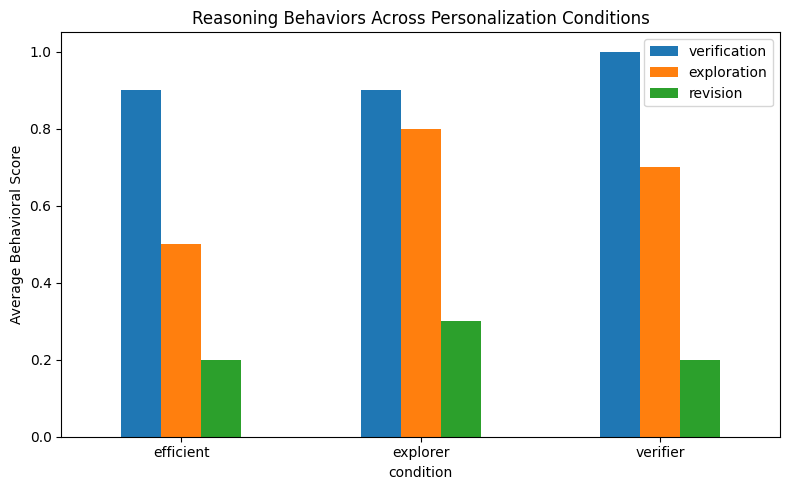

In [ ]:
#make graph
means = (
    labels
    .groupby("condition")[
        [
            "verification",
            "exploration",
            "revision"
        ]
    ]
    .mean()
)

means.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title(
    "Reasoning Behaviors Across Personalization Conditions"
)

plt.ylabel(
    "Average Behavioral Score"
)

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()